# Regressão Linear Simples
Vimos que para a regressão linear simples, temos o modelo:  $Y \approx \beta_0 + \beta_1 X$

Vamos implementar esse método a seguir. Inicialmente, definimos os dados.

$Y$ Variável Dependente (Resposta) - O que você quer prever ou entender o comportamento.

$X$ Variável Independente (Preditora) - O dado que você usa para fazer a previsão.

$\beta_0$ Intercepto (Coeficiente Linear) - O ponto de partida. É o valor esperado de $Y$ quando $X$ é exatamente zero. Visualmente, é onde a linha "corta" o eixo vertical.

$\beta_1$ Inclinação (Coeficiente Angular) - O "peso" da relação. Mostra o quanto $Y$ sobe (ou desce) para cada 1 unidade a mais de $X$. É o que dá o ângulo da reta.

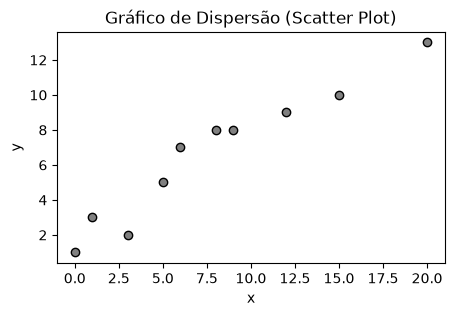

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# define os dados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])

# mostra os dados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.title('Gráfico de Dispersão (Scatter Plot)')
plt.show()

## Método dos Mínimos Quadrados Ordinários (MQO / OLS)

O objetivo do **Método dos Mínimos Quadrados** é determinar os valores de $\beta_0$ e $\beta_1$ que **minimizam a Soma dos Quadrados dos Resíduos (SQR)**:

$$\text{SQR} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n (y_i - (\beta_0 + \beta_1 x_i))^2$$

As fórmulas analíticas para calcular os coeficientes são:

$$\beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{\text{Cov}(X, Y)}{\text{Var}(X)}$$

$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

b_1 = S_xy / S_xx -> S_xy é o numerador (parte de cima da fração) S_xx é o denominador (parte de baixo da fração)

A covariância não é entre dois pontos, mas sim entre as duas variáveis $X$ e $Y$ ao longo de todo o conjunto de dados.

(x[i] - m_x) mede o quanto o ponto $x_i$ se desviou da média $\bar{x}$.
(y[i] - m_y) mede o quanto o ponto $y_i$ se desviou da média $\bar{y}$.
O produto (x[i] - m_x) * (y[i] - m_y) mostra se, para aquele ponto $i$, $X$ e $Y$ variam na mesma direção (ambos acima ou ambos abaixo de suas médias) ou em direções opostas.
O laço for soma esse produto para todos os pontos, gerando a Soma dos Produtos dos Desvios ($S_{xy}$).

Variável $X$ (Eixo horizontal - Independente): É a variável de controle ou explicação. E sim, pode ser o Tempo (dias, meses, anos, horas, idade).
Variável $Y$ (Eixo vertical - Dependente): É a variável de interesse que você quer medir ou prever (ex: temperatura, vendas, desmatamento, nível de um rio, preço).

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# função para calcular os coeficientes
def estimate_coef(x, y):
    n = np.size(x) # número de observações
    # valores médios das observações
    m_x, m_y = np.mean(x), np.mean(y)
    S_xy = 0
    S_xx = 0
    # calcula a covariância e variância
    for i in range(0, len(x)):
        S_xy = S_xy + (x[i]-m_x)*(y[i]-m_y)
        S_xx = S_xx + (x[i]-m_x)**2
    # calcula os coeficientes do modelo
    b_1 = S_xy / S_xx
    b_0 = m_y - b_1*m_x
    return(b_0, b_1)

# dados observados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])

# realiza o ajuste
b = estimate_coef(x, y)
y_pred = b[0] + b[1]*x
print('Coeficientes estimados:')
print('Theta0:', b[0])
print('Theta1:', b[1])


# mostra os dados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra o modelo ajustado
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.show()